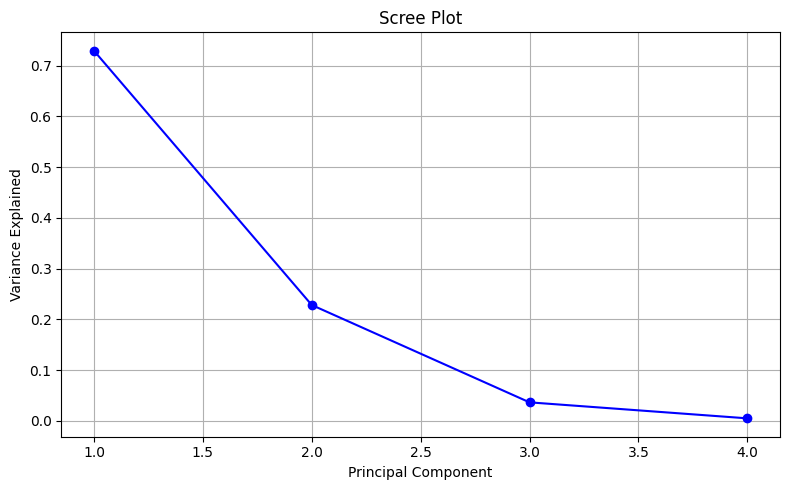

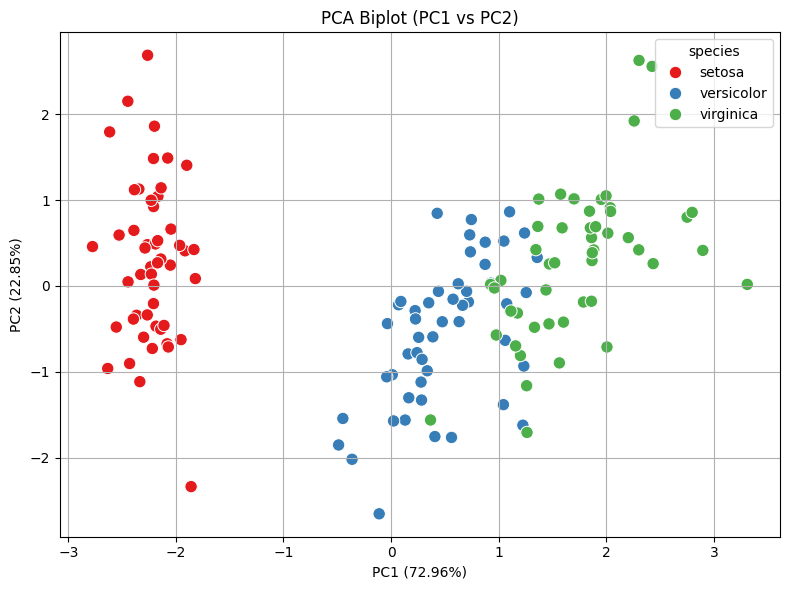

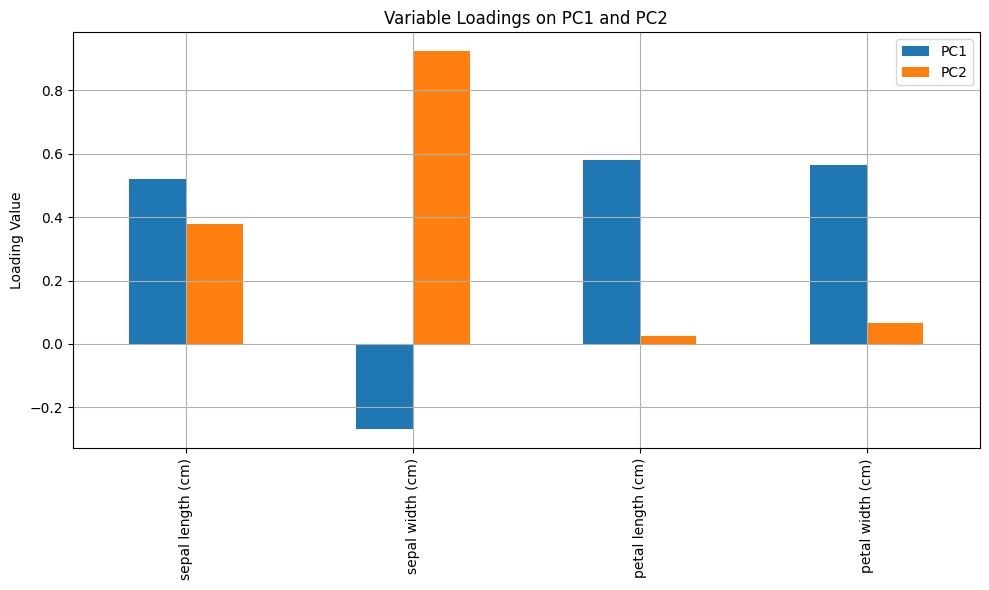

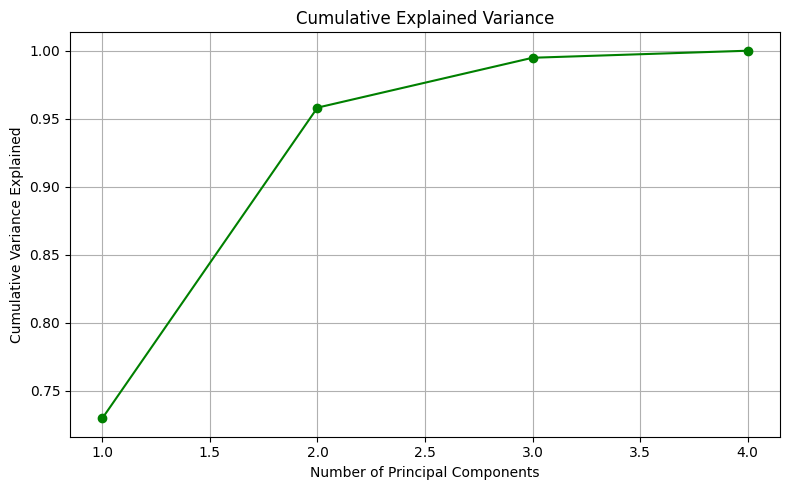

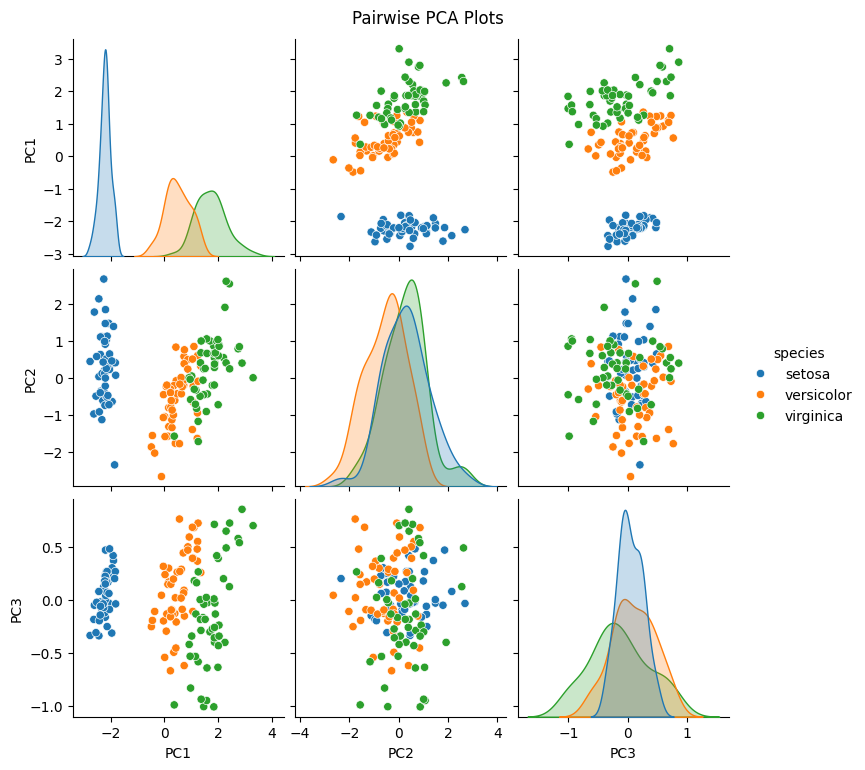

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
features = iris.feature_names
target_names = iris.target_names

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_variance)

# Create DataFrame for PCA results
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['species'] = [target_names[i] for i in y]

# =========================
# 1. Scree Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 2. PCA Biplot (PC1 vs PC2)
# =========================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species', palette='Set1', s=80)
plt.title('PCA Biplot (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]:.2%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%})')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 3. Loadings Plot (PC1 & PC2)
# =========================
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
loadings[['PC1', 'PC2']].plot(kind='bar', figsize=(10, 6))
plt.title('Variable Loadings on PC1 and PC2')
plt.ylabel('Loading Value')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 4. Cumulative Variance Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='green')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 5. Pairwise PCA Plots
# =========================
sns.pairplot(df_pca, hue='species', vars=['PC1', 'PC2', 'PC3'])
plt.suptitle("Pairwise PCA Plots", y=1.02)
plt.show()

# =========================
# 6. 3D PCA Plot
# =========================
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='species', title='3D PCA Plot')
fig.show()
